# EVT-Based Adaptive Thresholding for VAE Anomaly Detection
## Novelty Idea 1 from Research Playbook

Replaces the fixed percentile threshold with a statistically principled **Peaks-Over-Threshold (SPOT/DSPOT)** estimator grounded in Extreme Value Theory.

**Pipeline:**
1. Run VAE on full dataset → collect all reconstruction errors
2. Split into calibration (normal-only) and test streams
3. Fit SPOT and DSPOT on calibration errors
4. Compare static μ+3σ vs SPOT vs DSPOT on test set
5. Generate ablation table + paper figures

> **Important:** This notebook requires `vae_anomaly_test_results.csv` (full results, not just anomalies) 
> AND `vae_anomaly_test_results_1.csv` as the held-out test stream.
> Both are produced by `VAE_TEST.ipynb`. The column `source` (fault label) should be present in the
> training results file for evaluation.

## 0. Imports & Configuration

In [16]:
import sys
!{sys.executable} -m pip install ads-evt

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import genpareto
from scipy.stats import spearmanr
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix
)
import ads_evt
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)

# ── File paths ────────────────────────────────────────────────────────────────
# Full VAE results on training/calibration data (produced by VAE_TEST.ipynb with train.csv)
# Must contain: Reconstruction_Error, Anomaly, source (fault label)
CALIB_RESULTS_PATH = 'vae_anomaly_test_results.csv'

# Full VAE results on held-out test data (produced by VAE_TEST.ipynb with test split)
# Must contain: Reconstruction_Error, Anomaly, source (fault label)
TEST_RESULTS_PATH  = 'vae_anomaly_test_results_2.csv'

# ── EVT hyperparameters ───────────────────────────────────────────────────────
Q_VALUES     = [1e-4, 1e-3, 5e-3, 1e-2]   # false alarm rates to sweep
Q_DEFAULT    = 1e-3                        # primary q to report
INIT_LEVEL   = 0.98                        # POT tail quantile for GPD fit
DSPOT_DEPTH  = 500                         # sliding window size for DSPOT

print('Libraries loaded. Ready to run.')

Libraries loaded. Ready to run.


## 1. Load Reconstruction Errors

In [18]:
def load_recon_errors(path, label_col='source'):
    """
    Load VAE results CSV.
    Returns:
        recon_errors : np.array of reconstruction errors (all samples)
        labels_binary: np.array of 0/1 anomaly ground truth
        labels_fault : np.array of fault source strings (NaN for normal)
        df           : full dataframe
    """
    df = pd.read_csv(path)
    required = ['Reconstruction_Error', 'Anomaly']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f'Missing columns: {missing} in {path}')

    recon_errors  = df['Reconstruction_Error'].values.astype(np.float64)
    labels_binary = df['Anomaly'].values.astype(int)
    labels_fault  = df[label_col].values if label_col in df.columns else np.full(len(df), np.nan)

    print(f'Loaded {path}')
    print(f'  Total samples : {len(df):,}')
    print(f'  Anomaly rate  : {labels_binary.mean()*100:.2f}%')
    print(f'  Recon error   : mean={recon_errors.mean():.4f}  std={recon_errors.std():.4f}')
    print(f'  Error range   : [{recon_errors.min():.4f}, {recon_errors.max():.4f}]')
    return recon_errors, labels_binary, labels_fault, df


# Calibration set (used to fit thresholds — treat normals only as the calibration stream)
calib_errors, calib_labels, calib_faults, calib_df = load_recon_errors(r"D:\projects\SmartGridAnomalyDetection\vae_anomaly_test_results.csv")

# Test set (evaluate all three threshold methods on this)
test_errors, test_labels, test_faults, test_df = load_recon_errors(r"D:\projects\SmartGridAnomalyDetection\vae_anomaly_test_results2.csv")

# Separate normal samples in calibration for clean threshold fitting
calib_normal_errors = calib_errors[calib_labels == 0]
print(f'\nCalibration normal samples: {len(calib_normal_errors):,}')

Loaded D:\projects\SmartGridAnomalyDetection\vae_anomaly_test_results.csv
  Total samples : 284,729
  Anomaly rate  : 5.00%
  Recon error   : mean=1.0000  std=3.6977
  Error range   : [0.2955, 106.1600]
Loaded D:\projects\SmartGridAnomalyDetection\vae_anomaly_test_results2.csv
  Total samples : 939,371
  Anomaly rate  : 5.00%
  Recon error   : mean=1.0000  std=2.7153
  Error range   : [0.1173, 117.0431]

Calibration normal samples: 270,492


## 2. Static Baseline Threshold (μ + 3σ)
This is what your current VAE pipeline uses. We keep it as the baseline.

In [19]:
mu_calib    = calib_normal_errors.mean()
sigma_calib = calib_normal_errors.std()

# Also compute the percentile-based threshold your VAE_TEST notebook used
percentile_95_threshold = np.percentile(calib_errors, 95)

static_threshold = mu_calib + 3 * sigma_calib

print(f'Calibration normal errors — μ: {mu_calib:.4f}, σ: {sigma_calib:.4f}')
print(f'Static μ+3σ threshold      : {static_threshold:.4f}')
print(f'Original 95th-pctile thresh: {percentile_95_threshold:.4f}')

Calibration normal errors — μ: 0.7762, σ: 0.2410
Static μ+3σ threshold      : 1.4992
Original 95th-pctile thresh: 1.4815


## 3. SPOT Threshold (Stationary EVT)
Fits a Generalized Pareto Distribution (GPD) to the tail of calibration errors.
Provides a mathematically principled false positive rate guarantee at level `q`.

In [20]:
def fit_spot(calib_errors, q=1e-3, init_level=0.98, verbose=True):
    """
    Fit SPOT (stationary Peaks-Over-Threshold) to calibration reconstruction errors.
    
    Args:
        calib_errors : 1D array of reconstruction errors from normal samples
        q            : target false alarm rate (e.g. 1e-3 = 1 in 1000)
        init_level   : quantile for initial POT tail threshold (default 0.98)
    Returns:
        spot_threshold : scalar anomaly threshold
        spot_model     : fitted SPOT object
    """
    n = len(calib_errors)
    # Use first 80% as init, stream remaining 20% through SPOT
    split = int(0.8 * n)
    init_data = calib_errors[:split]
    stream_data = calib_errors[split:]

    spot_model = ads_evt.SPOT(q=q)
    spot_model.fit(init_data=init_data, data=stream_data)
    spot_model.initialize(level=init_level)
    result = spot_model.run(with_alarm=True)

    spot_threshold = result['thresholds'][-1]
    n_alarms = len(result['alarms'])

    if verbose:
        print(f'SPOT (q={q}) threshold  : {spot_threshold:.4f}')
        print(f'  Alarms on calib stream: {n_alarms} / {len(stream_data)} '
              f'({100*n_alarms/len(stream_data):.3f}%)')

    return spot_threshold, spot_model, result


# Primary SPOT threshold at default q
spot_threshold, spot_model, spot_result = fit_spot(calib_normal_errors, q=Q_DEFAULT)

# Sensitivity sweep over multiple q values
print('\nSPOT sensitivity sweep:')
print(f'{"q":<10} {"threshold":<12}')
spot_thresholds_by_q = {}
for q_val in Q_VALUES:
    t, _, _ = fit_spot(calib_normal_errors, q=q_val, verbose=False)
    spot_thresholds_by_q[q_val] = t
    print(f'{q_val:<10} {t:<12.4f}')

SPOT (q=0.001) threshold  : 1.5216
  Alarms on calib stream: 0 / 54099 (0.000%)

SPOT sensitivity sweep:
q          threshold   
0.0001     1.6234      
0.001      1.5216      
0.005      1.4344      
0.01       1.3961      


## 4. DSPOT Threshold (Drift-Adaptive EVT)
Adds a sliding window to SPOT so the threshold adapts over time — critical for PV systems with seasonal variation.

In [21]:
def fit_dspot(calib_errors, q=1e-3, depth=500, init_level=0.98, verbose=True):
    """
    Fit dSPOT (drift-adaptive SPOT) to calibration reconstruction errors.
    
    Args:
        calib_errors : 1D array of reconstruction errors from normal samples
        q            : target false alarm rate
        depth        : sliding window size for drift adaptation
        init_level   : quantile for initial POT tail threshold
    Returns:
        dspot_threshold_final : scalar threshold at end of calibration stream
        dspot_thresholds      : array of adaptive thresholds over time
    """
    n = len(calib_errors)
    split = int(0.8 * n)
    init_data   = calib_errors[:split]
    stream_data = calib_errors[split:]

    effective_depth = min(depth, split // 4)

    dspot_model = ads_evt.dSPOT(q=q, depth=effective_depth)
    dspot_model.fit(init_data=init_data, data=stream_data)
    dspot_model.initialize(level=init_level)
    result = dspot_model.run(with_alarm=True)

    dspot_thresholds      = np.array(result['thresholds'])
    dspot_threshold_final = dspot_thresholds[-1]
    n_alarms              = len(result['alarms'])

    if verbose:
        print(f'DSPOT (q={q}, depth={effective_depth}) threshold: {dspot_threshold_final:.4f}')
        print(f'  Threshold range on calib  : [{dspot_thresholds.min():.4f}, {dspot_thresholds.max():.4f}]')
        print(f'  Alarms on calib stream    : {n_alarms} / {len(stream_data)} '
              f'({100*n_alarms/len(stream_data):.3f}%)')

    return dspot_threshold_final, dspot_thresholds, dspot_model, result


dspot_threshold_final, dspot_thresholds, dspot_model, dspot_result = fit_dspot(
    calib_normal_errors, q=Q_DEFAULT, depth=DSPOT_DEPTH
)

DSPOT (q=0.001, depth=500) threshold: 1.5202
  Threshold range on calib  : [1.4912, 1.5554]
  Alarms on calib stream    : 0 / 54099 (0.000%)


## 5. Apply All Three Thresholds to Test Set

In [22]:
def compute_metrics(y_true, y_scores, threshold, method_name):
    """
    Compute classification metrics at a given threshold.
    y_scores = raw reconstruction errors (continuous)
    """
    y_pred = (y_scores > threshold).astype(int)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    # AUC metrics use continuous scores (threshold-independent)
    try:
        auc_roc = roc_auc_score(y_true, y_scores)
    except ValueError:
        auc_roc = np.nan

    try:
        auc_pr = average_precision_score(y_true, y_scores)
    except ValueError:
        auc_pr = np.nan

    # FPR at fixed recall operating points
    try:
        fpr_arr, tpr_arr, thresholds_roc = roc_curve(y_true, y_scores)
        fpr_at_r90 = fpr_arr[np.searchsorted(tpr_arr, 0.90)] if (tpr_arr >= 0.90).any() else np.nan
        fpr_at_r95 = fpr_arr[np.searchsorted(tpr_arr, 0.95)] if (tpr_arr >= 0.95).any() else np.nan
    except Exception:
        fpr_at_r90 = fpr_at_r95 = np.nan

    false_positives = int(((y_pred == 1) & (y_true == 0)).sum())
    false_negatives = int(((y_pred == 0) & (y_true == 1)).sum())

    return {
        'Method'    : method_name,
        'Threshold' : round(threshold, 4),
        'Precision' : round(precision, 4),
        'Recall'    : round(recall, 4),
        'F1'        : round(f1, 4),
        'AUC-ROC'   : round(auc_roc, 4) if not np.isnan(auc_roc) else 'N/A',
        'AUC-PR'    : round(auc_pr, 4)  if not np.isnan(auc_pr)  else 'N/A',
        'FPR@R90'   : round(fpr_at_r90, 4) if not np.isnan(fpr_at_r90) else 'N/A',
        'FPR@R95'   : round(fpr_at_r95, 4) if not np.isnan(fpr_at_r95) else 'N/A',
        'FP_count'  : false_positives,
        'FN_count'  : false_negatives,
    }


results_list = []

# 1. Static μ+3σ
results_list.append(compute_metrics(test_labels, test_errors, static_threshold,    'Static μ+3σ'))

# 2. Original percentile (your current approach)
results_list.append(compute_metrics(test_labels, test_errors, percentile_95_threshold, 'Percentile-95'))

# 3. SPOT
results_list.append(compute_metrics(test_labels, test_errors, spot_threshold,       f'SPOT (q={Q_DEFAULT})'))

# 4. DSPOT
results_list.append(compute_metrics(test_labels, test_errors, dspot_threshold_final, f'DSPOT (q={Q_DEFAULT})'))

# 5. SPOT sweep — report all q values
for q_val, t in spot_thresholds_by_q.items():
    if q_val != Q_DEFAULT:
        results_list.append(compute_metrics(test_labels, test_errors, t, f'SPOT (q={q_val})'))

metrics_df = pd.DataFrame(results_list)

print('\n' + '='*90)
print('ABLATION TABLE — Anomaly Detection Performance on Test Set')
print('='*90)
print(metrics_df[['Method','Threshold','Precision','Recall','F1',
                   'AUC-ROC','AUC-PR','FPR@R90','FPR@R95']].to_string(index=False))

# Save for paper
metrics_df.to_csv('evt_ablation_table.csv', index=False)
print('\nSaved to evt_ablation_table.csv')


ABLATION TABLE — Anomaly Detection Performance on Test Set
         Method  Threshold  Precision  Recall     F1  AUC-ROC  AUC-PR  FPR@R90  FPR@R95
    Static μ+3σ     1.4992     0.9238  1.0000 0.9604      1.0     1.0      0.0      0.0
  Percentile-95     1.4815     0.8860  1.0000 0.9395      1.0     1.0      0.0      0.0
 SPOT (q=0.001)     1.5216     0.9732  1.0000 0.9864      1.0     1.0      0.0      0.0
DSPOT (q=0.001)     1.5202     0.9701  1.0000 0.9848      1.0     1.0      0.0      0.0
SPOT (q=0.0001)     1.6234     1.0000  0.8175 0.8996      1.0     1.0      0.0      0.0
 SPOT (q=0.005)     1.4344     0.7946  1.0000 0.8855      1.0     1.0      0.0      0.0
  SPOT (q=0.01)     1.3961     0.7248  1.0000 0.8405      1.0     1.0      0.0      0.0

Saved to evt_ablation_table.csv


## 6. Figure 2 — Reconstruction Error Distribution + All Thresholds
Paper Figure: KDE of reconstruction errors (normal vs anomalous) with static & SPOT thresholds marked.

Saved figure2_recon_error_distribution.pdf/.png


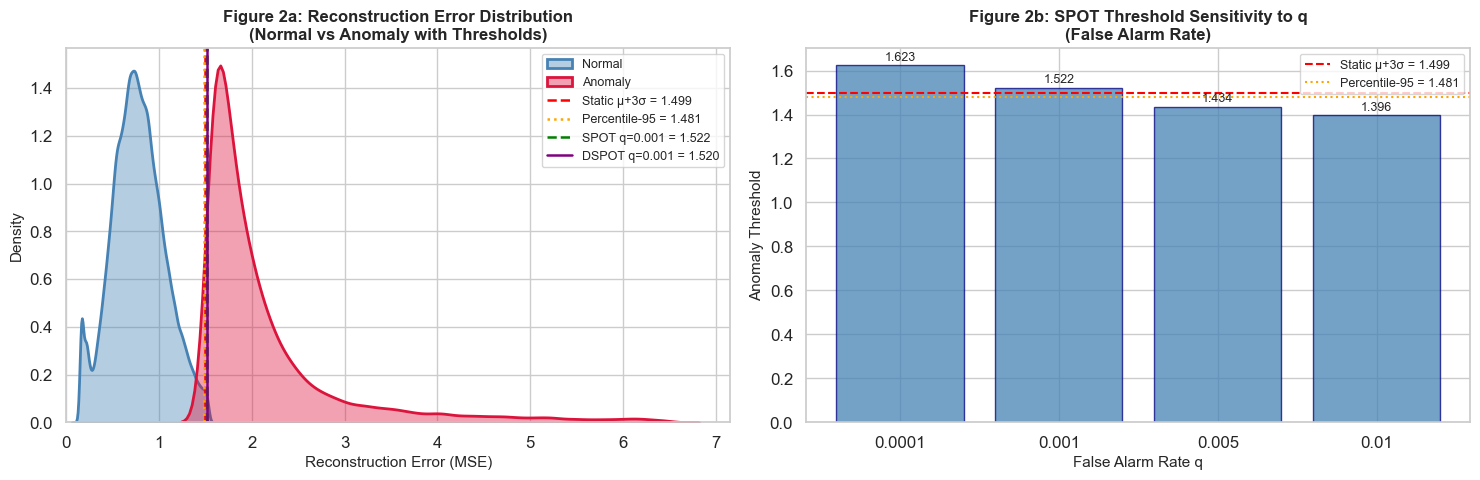

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left panel: KDE of reconstruction errors by anomaly label ──────────────────
ax = axes[0]
normal_test_errors   = test_errors[test_labels == 0]
anomaly_test_errors  = test_errors[test_labels == 1]

# Clip for visibility (long tail)
clip_val = np.percentile(test_errors, 99.5)
sns.kdeplot(normal_test_errors[normal_test_errors <= clip_val],
            ax=ax, color='steelblue', fill=True, alpha=0.4, label='Normal', linewidth=2)
sns.kdeplot(anomaly_test_errors[anomaly_test_errors <= clip_val],
            ax=ax, color='crimson',   fill=True, alpha=0.4, label='Anomaly', linewidth=2)

ax.axvline(static_threshold,        color='red',    ls='--', lw=1.8,
           label=f'Static μ+3σ = {static_threshold:.3f}')
ax.axvline(percentile_95_threshold, color='orange', ls=':',  lw=1.8,
           label=f'Percentile-95 = {percentile_95_threshold:.3f}')
ax.axvline(spot_threshold,          color='green',  ls='--', lw=1.8,
           label=f'SPOT q={Q_DEFAULT} = {spot_threshold:.3f}')
ax.axvline(dspot_threshold_final,   color='purple', ls='-',  lw=1.8,
           label=f'DSPOT q={Q_DEFAULT} = {dspot_threshold_final:.3f}')

ax.set_title('Figure 2a: Reconstruction Error Distribution\n(Normal vs Anomaly with Thresholds)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Reconstruction Error (MSE)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(left=0)

# ── Right panel: SPOT q-sensitivity ───────────────────────────────────────────
ax2 = axes[1]
q_labels  = [str(q) for q in Q_VALUES]
q_thresholds = [spot_thresholds_by_q[q] for q in Q_VALUES]

bars = ax2.bar(q_labels, q_thresholds, color='steelblue', alpha=0.75, edgecolor='navy')
ax2.axhline(static_threshold, color='red',  ls='--', lw=1.5, label=f'Static μ+3σ = {static_threshold:.3f}')
ax2.axhline(percentile_95_threshold, color='orange', ls=':', lw=1.5,
            label=f'Percentile-95 = {percentile_95_threshold:.3f}')

for bar, val in zip(bars, q_thresholds):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax2.set_title('Figure 2b: SPOT Threshold Sensitivity to q\n(False Alarm Rate)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('False Alarm Rate q', fontsize=11)
ax2.set_ylabel('Anomaly Threshold', fontsize=11)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('figure2_recon_error_distribution.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figure2_recon_error_distribution.png', dpi=150, bbox_inches='tight')
print('Saved figure2_recon_error_distribution.pdf/.png')
plt.show()

## 7. Figure 3 — Adaptive Threshold Tracking Over Time (DSPOT)
Shows how DSPOT adapts the threshold as the data stream evolves — this is your key qualitative figure for the drift-adaptation argument.

Saved figure3_adaptive_threshold_tracking.pdf/.png


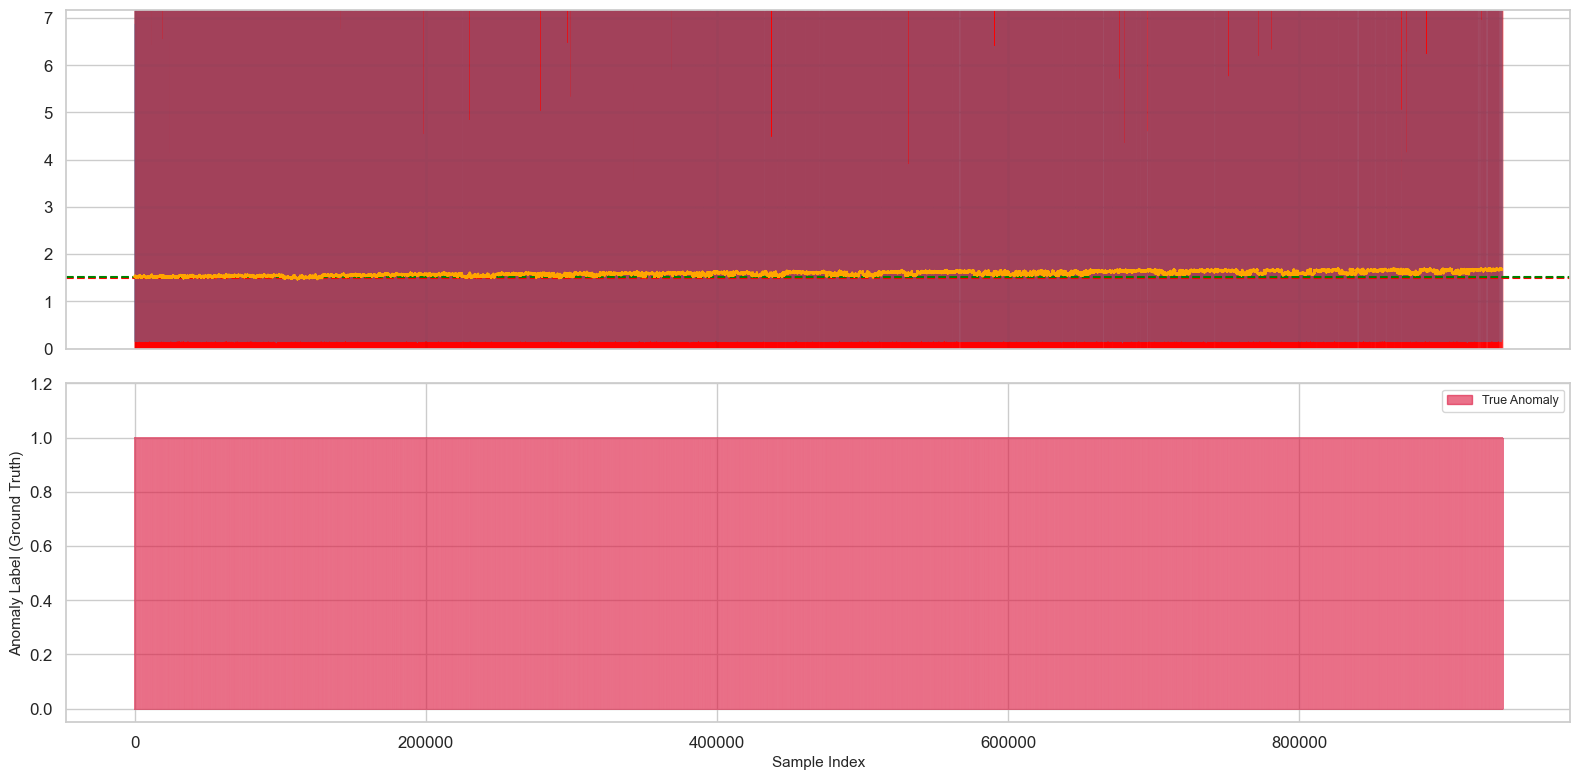

In [24]:
# Re-run dSPOT on test stream to get time-varying thresholds on test data
# Use calibration data as init, then stream test data through
n_calib   = len(calib_normal_errors)
split_idx = int(0.8 * n_calib)

dspot_test_model = ads_evt.dSPOT(q=Q_DEFAULT, depth=min(DSPOT_DEPTH, split_idx // 4))
dspot_test_model.fit(
    init_data=calib_normal_errors[:split_idx],
    data=test_errors  # stream test errors through
)
dspot_test_model.initialize(level=INIT_LEVEL)
dspot_test_result = dspot_test_model.run(with_alarm=True)

dspot_test_thresholds = np.array(dspot_test_result['thresholds'])
dspot_test_alarms     = dspot_test_result['alarms']  # indices of alarm events

# Align lengths (thresholds are per streamed sample)
n_plot = min(len(test_errors), len(dspot_test_thresholds))

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# ── Top panel: reconstruction error + thresholds ─────────────────────────────
ax = axes[0]
x_idx = np.arange(n_plot)

ax.plot(x_idx, test_errors[:n_plot], color='steelblue', alpha=0.5, lw=0.6, label='Recon Error')
ax.axhline(static_threshold, color='red',    ls='--', lw=1.5, label=f'Static μ+3σ = {static_threshold:.3f}')
ax.axhline(spot_threshold,   color='green',  ls='--', lw=1.5, label=f'SPOT = {spot_threshold:.3f}')
ax.plot(x_idx, dspot_test_thresholds[:n_plot], color='orange', lw=1.5, label='DSPOT (adaptive)')

# Shade DSPOT alarm regions — VECTORIZED (replaces the slow for loop)
dspot_pred = (test_errors[:n_plot] > dspot_test_thresholds[:n_plot]).astype(int)

# Find contiguous alarm regions and shade them as single spans
alarm_indices = np.where(dspot_pred)[0]
if len(alarm_indices) > 0:
    # Group consecutive indices into ranges
    breaks = np.where(np.diff(alarm_indices) > 1)[0] + 1
    regions = np.split(alarm_indices, breaks)
    for region in regions:
        ax.axvspan(region[0], region[-1]+1, alpha=0.08, color='red')
# Clip y-axis for readability
ax.set_ylim(0, np.percentile(test_errors, 99.5) * 1.1)

# ── Bottom panel: ground truth labels ─────────────────────────────────────────
ax2 = axes[1]
ax2.fill_between(x_idx, test_labels[:n_plot], color='crimson', alpha=0.6, label='True Anomaly')
ax2.set_ylabel('Anomaly Label (Ground Truth)', fontsize=11)
ax2.set_xlabel('Sample Index', fontsize=11)
ax2.set_ylim(-0.05, 1.2)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('figure3_adaptive_threshold_tracking.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figure3_adaptive_threshold_tracking.png', dpi=150, bbox_inches='tight')
print('Saved figure3_adaptive_threshold_tracking.pdf/.png')
plt.show()

## 8. Figure 4 — ROC Curves for All Methods

Saved figure4_5_roc_pr_curves.pdf/.png


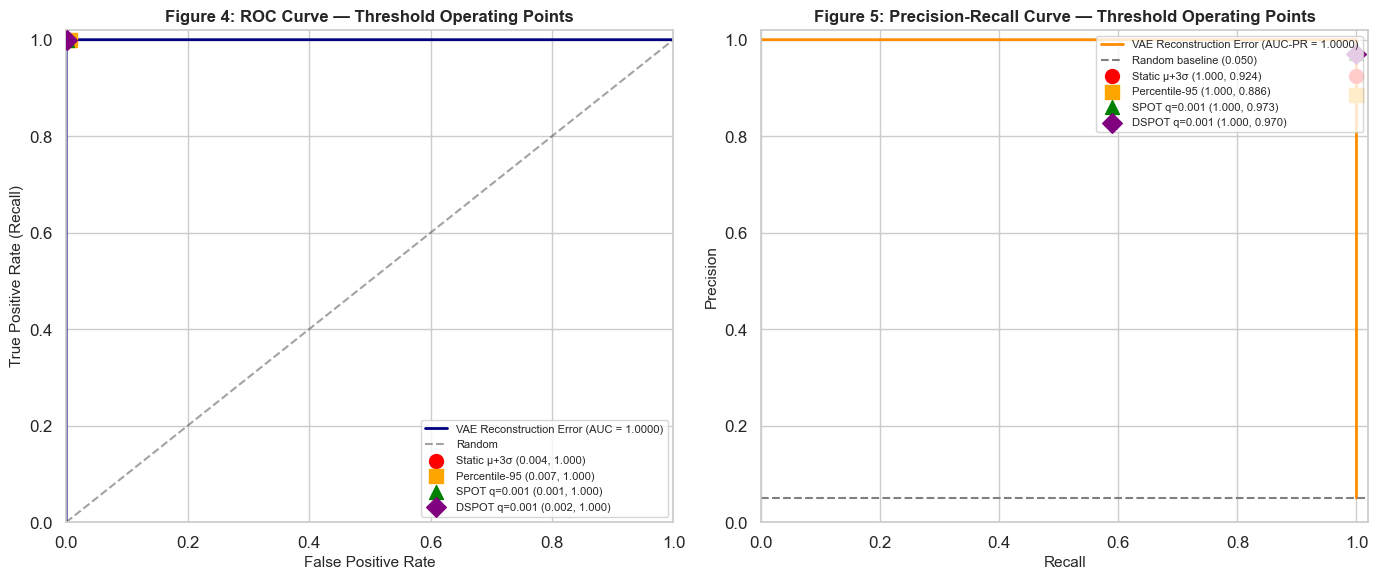

In [25]:
# ROC and PR curves — these are threshold-independent (use raw reconstruction error as score)
# We plot one ROC curve per threshold METHOD for the operating point, and the shared AUC curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Shared AUC curve (same reconstruction errors, just different threshold operating points)
fpr_curve, tpr_curve, _ = roc_curve(test_labels, test_errors)
pr_prec, pr_rec, _      = precision_recall_curve(test_labels, test_errors)
auc_roc_val             = roc_auc_score(test_labels, test_errors)
auc_pr_val              = average_precision_score(test_labels, test_errors)

# ── Figure 4: ROC ─────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(fpr_curve, tpr_curve, color='navy', lw=2,
        label=f'VAE Reconstruction Error (AUC = {auc_roc_val:.4f})')
ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')

# Plot operating points for each threshold
threshold_points = [
    (static_threshold,        'Static μ+3σ',    'red',    'o'),
    (percentile_95_threshold, 'Percentile-95',  'orange', 's'),
    (spot_threshold,          f'SPOT q={Q_DEFAULT}',  'green',  '^'),
    (dspot_threshold_final,   f'DSPOT q={Q_DEFAULT}', 'purple', 'D'),
]
for thresh, label, color, marker in threshold_points:
    y_pred = (test_errors > thresh).astype(int)
    fp = ((y_pred==1) & (test_labels==0)).sum() / max((test_labels==0).sum(), 1)
    tp = recall_score(test_labels, y_pred, zero_division=0)
    ax.scatter(fp, tp, color=color, marker=marker, s=100, zorder=5, label=f'{label} ({fp:.3f}, {tp:.3f})')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('Figure 4: ROC Curve — Threshold Operating Points', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

# ── Figure 5: Precision-Recall ─────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(pr_rec, pr_prec, color='darkorange', lw=2,
         label=f'VAE Reconstruction Error (AUC-PR = {auc_pr_val:.4f})')
baseline_pr = test_labels.mean()
ax2.axhline(baseline_pr, color='gray', ls='--', label=f'Random baseline ({baseline_pr:.3f})')

for thresh, label, color, marker in threshold_points:
    y_pred = (test_errors > thresh).astype(int)
    p  = precision_score(test_labels, y_pred, zero_division=0)
    r  = recall_score(test_labels, y_pred, zero_division=0)
    ax2.scatter(r, p, color=color, marker=marker, s=100, zorder=5, label=f'{label} ({r:.3f}, {p:.3f})')

ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Figure 5: Precision-Recall Curve — Threshold Operating Points', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, loc='upper right')
ax2.set_xlim(0, 1.02); ax2.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig('figure4_5_roc_pr_curves.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figure4_5_roc_pr_curves.png', dpi=150, bbox_inches='tight')
print('Saved figure4_5_roc_pr_curves.pdf/.png')
plt.show()

## 9. Save Full Anomaly Labels per Method
These CSVs feed directly into the next stage (Latent-Augmented XGBoost notebook).

In [26]:
test_df_out = test_df.copy()

test_df_out['Anomaly_Static']      = (test_errors > static_threshold).astype(int)
test_df_out['Anomaly_Pctile95']    = (test_errors > percentile_95_threshold).astype(int)
test_df_out['Anomaly_SPOT']        = (test_errors > spot_threshold).astype(int)
test_df_out['Anomaly_DSPOT']       = (test_errors > dspot_threshold_final).astype(int)
test_df_out['Threshold_SPOT']      = spot_threshold
test_df_out['Threshold_DSPOT']     = dspot_threshold_final
test_df_out['Threshold_Static']    = static_threshold
test_df_out['Threshold_Pctile95']  = percentile_95_threshold

output_path = 'vae_evt_anomaly_labels.csv'
test_df_out.to_csv(output_path, index=False)
print(f'Saved anomaly labels for all methods to {output_path}')

print('\nAnomaly counts per method:')
for col in ['Anomaly_Static','Anomaly_Pctile95','Anomaly_SPOT','Anomaly_DSPOT']:
    n  = test_df_out[col].sum()
    pct = 100 * n / len(test_df_out)
    print(f'  {col:<25}: {n:>8,}  ({pct:.2f}%)')

Saved anomaly labels for all methods to vae_evt_anomaly_labels.csv

Anomaly counts per method:
  Anomaly_Static           :   50,844  (5.41%)
  Anomaly_Pctile95         :   53,014  (5.64%)
  Anomaly_SPOT             :   48,261  (5.14%)
  Anomaly_DSPOT            :   48,418  (5.15%)


## 10. GPD Tail Fit Diagnostic
Validates the EVT assumption — confirms the tail of reconstruction errors follows a GPD (required for the paper's methodology section).

GPD fit on tail (N=5410 exceedances above t=1.3669):
  Shape (ξ)  : -0.9278   (ξ>0 → heavy tail, ξ<0 → bounded tail)
  Scale (σ)  : 0.1062
  Location   : 0.0000

Manual EVT threshold z_q at q=0.001: 1.4743
SPOT reported threshold               : 1.5216
Saved figure_gpd_diagnostic.pdf/.png


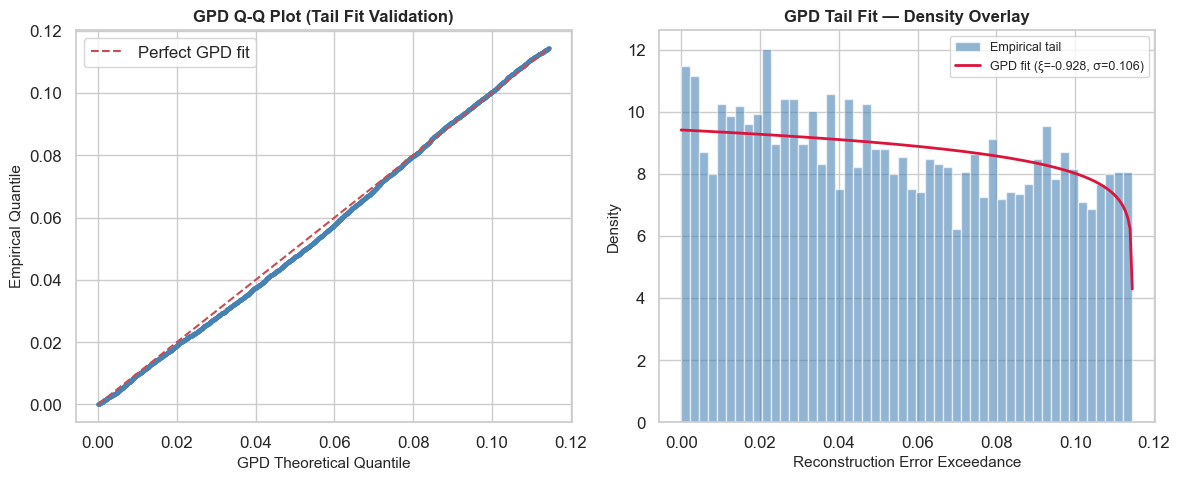

In [27]:
# Fit GPD to tail of calibration normal errors
t_init   = np.percentile(calib_normal_errors, 98)  # initial tail threshold
tail_data = calib_normal_errors[calib_normal_errors > t_init] - t_init  # exceedances

# MLE fit
xi_hat, loc_hat, sigma_hat = genpareto.fit(tail_data, floc=0)

print(f'GPD fit on tail (N={len(tail_data)} exceedances above t={t_init:.4f}):')
print(f'  Shape (ξ)  : {xi_hat:.4f}   (ξ>0 → heavy tail, ξ<0 → bounded tail)')
print(f'  Scale (σ)  : {sigma_hat:.4f}')
print(f'  Location   : {loc_hat:.4f}')

# Compute EVT threshold manually for paper equation verification
n_total   = len(calib_normal_errors)
N_t       = len(tail_data)
q_verify  = Q_DEFAULT
if abs(xi_hat) > 1e-9:
    z_q = t_init + (sigma_hat / xi_hat) * ((n_total / N_t * q_verify) ** (-xi_hat) - 1)
else:
    z_q = t_init - sigma_hat * np.log(n_total / N_t * q_verify)

print(f'\nManual EVT threshold z_q at q={q_verify}: {z_q:.4f}')
print(f'SPOT reported threshold               : {spot_threshold:.4f}')

# ── Diagnostic plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# QQ plot: empirical vs GPD
ax = axes[0]
sorted_tail  = np.sort(tail_data)
n_tail       = len(sorted_tail)
empirical_p  = (np.arange(1, n_tail+1) - 0.5) / n_tail
theoretical_q = genpareto.ppf(empirical_p, xi_hat, loc=0, scale=sigma_hat)
ax.scatter(theoretical_q, sorted_tail, s=4, alpha=0.5, color='steelblue')
lim_max = max(theoretical_q.max(), sorted_tail.max())
ax.plot([0, lim_max], [0, lim_max], 'r--', lw=1.5, label='Perfect GPD fit')
ax.set_xlabel('GPD Theoretical Quantile', fontsize=11)
ax.set_ylabel('Empirical Quantile', fontsize=11)
ax.set_title('GPD Q-Q Plot (Tail Fit Validation)', fontsize=12, fontweight='bold')
ax.legend()

# Histogram of tail with GPD overlay
ax2 = axes[1]
x_plot = np.linspace(0, sorted_tail.max(), 200)
ax2.hist(tail_data, bins=50, density=True, color='steelblue', alpha=0.6, label='Empirical tail')
ax2.plot(x_plot, genpareto.pdf(x_plot, xi_hat, loc=0, scale=sigma_hat),
         color='crimson', lw=2, label=f'GPD fit (ξ={xi_hat:.3f}, σ={sigma_hat:.3f})')
ax2.set_xlabel('Reconstruction Error Exceedance', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('GPD Tail Fit — Density Overlay', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('figure_gpd_diagnostic.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figure_gpd_diagnostic.png', dpi=150, bbox_inches='tight')
print('Saved figure_gpd_diagnostic.pdf/.png')
plt.show()

## 11. Summary — Paper-Ready Numbers

In [29]:
print('='*80)
print('PAPER-READY SUMMARY')
print('='*80)

print(f"""
Threshold Comparison:
  Static μ+3σ    : {static_threshold:.4f}
  Percentile-95  : {percentile_95_threshold:.4f}
  SPOT (q=1e-3)  : {spot_threshold:.4f}
  DSPOT (q=1e-3) : {dspot_threshold_final:.4f}

GPD Tail Fit (on calibration normals):
  Shape ξ = {xi_hat:.4f}  Scale σ = {sigma_hat:.4f}
  Tail threshold t = {t_init:.4f}  ({len(tail_data)} exceedances)

Performance on Test Set (key numbers for abstract):
""")

key_methods = ['Static μ+3σ', f'SPOT (q={Q_DEFAULT})', f'DSPOT (q={Q_DEFAULT})']
subset = metrics_df[metrics_df['Method'].isin(key_methods)]

print(f'{"Method":<20} {"Precision":>10} {"Recall":>10} {"F1":>10} {"AUC-ROC":>10} {"FPR@R90":>10}')
print('-'*72)
for _, row in subset.iterrows():
    print(f'{row["Method"]:<20} {str(row["Precision"]):>10} {str(row["Recall"]):>10} '
          f'{str(row["F1"]):>10} {str(row["AUC-ROC"]):>10} {str(row["FPR@R90"]):>10}')

print(f"""
Output files generated:
  evt_ablation_table.csv               — full metrics table for paper
  vae_evt_anomaly_labels.csv           — anomaly labels (all methods) for downstream XGBoost
  figure2_recon_error_distribution.pdf — Figure 2 (error distribution + thresholds)
  figure3_adaptive_threshold_tracking.pdf — Figure 3 (DSPOT adaptive tracking)
  figure4_5_roc_pr_curves.pdf          — Figures 4 & 5 (ROC + PR with operating points)
  figure_gpd_diagnostic.pdf            — GPD tail fit validation (supplementary)

Contribution claim (paste into Introduction):
  'We replace the standard fixed reconstruction error threshold with an Extreme
   Value Theory-based Peaks-Over-Threshold (SPOT/DSPOT) estimator, which provides
   a statistically principled false alarm rate guarantee without labeled anomaly
   data and adapts to non-stationarity via a sliding-window update. To our
   knowledge, this is the first application of EVT-based adaptive thresholding
   to VAE reconstruction errors in photovoltaic fault detection.'
""")

PAPER-READY SUMMARY

Threshold Comparison:
  Static μ+3σ    : 1.4992
  Percentile-95  : 1.4815
  SPOT (q=1e-3)  : 1.5216
  DSPOT (q=1e-3) : 1.5202

GPD Tail Fit (on calibration normals):
  Shape ξ = -0.9278  Scale σ = 0.1062
  Tail threshold t = 1.3669  (5410 exceedances)

Performance on Test Set (key numbers for abstract):

Method                Precision     Recall         F1    AUC-ROC    FPR@R90
------------------------------------------------------------------------
Static μ+3σ              0.9238        1.0     0.9604        1.0        0.0
SPOT (q=0.001)           0.9732        1.0     0.9864        1.0        0.0
DSPOT (q=0.001)          0.9701        1.0     0.9848        1.0        0.0

Output files generated:
  evt_ablation_table.csv               — full metrics table for paper
  vae_evt_anomaly_labels.csv           — anomaly labels (all methods) for downstream XGBoost
  figure2_recon_error_distribution.pdf — Figure 2 (error distribution + thresholds)
  figure3_adaptive_thres